# Credit Risk — Exploratory Data Analysis
Runs full EDA on the **cleaned** dataset produced by `data_prep.ipynb`.

> ⚠️ Run `data_prep.ipynb` first to generate `data/ready_data.csv`.

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('Libraries loaded OK')

Libraries loaded OK


## 1. Load Cleaned Data

In [2]:
# Load the clean CSV saved by data_prep.ipynb
data_path = os.path.abspath(os.path.join('..', 'data', 'clean_cs_training.csv'))
df = pd.read_csv(data_path)

TARGET   = 'default'
FEATURES = [c for c in df.columns if c != TARGET]

print(f'Loaded : {data_path}')
print(f'Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded : c:\Users\User\Downloads\Credit-risk-prediction-main\Credit-risk-prediction-main\data\clean_cs_training.csv
Shape  : 149,391 rows x 15 columns
Columns: ['default', 'util_rate', 'age', 'late_30_59', 'debt_ratio', 'income', 'open_loans', 'late_90_plus', 'real_estate_loans', 'late_60_89', 'dependents', 'total_late', 'has_late_payment', 'income_per_dependent', 'debt_per_loan']


,default,util_rate,age,late_30_59,debt_ratio,income,open_loans,late_90_plus,real_estate_loans,late_60_89,dependents,total_late,has_late_payment,income_per_dependent,debt_per_loan
0,1,0.766127,45.0,2,0.802982,9120.0,13,0,6,0,2.0,2,1,3040.0,0.057356
1,0,0.957151,40.0,0,0.121876,2600.0,4,0,0,0,1.0,0,0,1300.0,0.024375
2,0,0.658180,38.0,1,0.085113,3042.0,2,1,0,0,0.0,2,1,3042.0,0.028371
3,0,0.233810,30.0,0,0.036050,3300.0,5,0,0,0,0.0,0,0,3300.0,0.006008
4,0,0.907239,49.0,1,0.024926,63588.0,7,0,1,0,0.0,1,1,63588.0,0.003116


## 2. Data Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149391 entries, 0 to 149390
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   default               149391 non-null  int64  
 1   util_rate             149391 non-null  float64
 2   age                   149391 non-null  float64
 3   late_30_59            149391 non-null  int64  
 4   debt_ratio            149391 non-null  float64
 5   income                149391 non-null  float64
 6   open_loans            149391 non-null  int64  
 7   late_90_plus          149391 non-null  int64  
 8   real_estate_loans     149391 non-null  int64  
 9   late_60_89            149391 non-null  int64  
 10  dependents            149391 non-null  float64
 11  total_late            149391 non-null  int64  
 12  has_late_payment      149391 non-null  int64  
 13  income_per_dependent  149391 non-null  float64
 14  debt_per_loan         149391 non-null  float64
dtypes: float64(

In [4]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
default,149391.0,0.067,0.250,0.0,0.000,0.000,0.000,1.000
util_rate,149391.0,6.071,250.264,0.0,0.030,0.154,0.556,50708.000
age,149391.0,52.307,14.725,21.0,41.000,52.000,63.000,109.000
late_30_59,149391.0,0.394,3.853,0.0,0.000,0.000,0.000,98.000
debt_ratio,149391.0,354.437,2041.843,0.0,0.177,0.368,0.875,329664.000
income,149391.0,6425.688,12915.669,0.0,3900.000,5400.000,7400.000,3008750.000
open_loans,149391.0,8.481,5.137,0.0,5.000,8.000,11.000,58.000
late_90_plus,149391.0,0.238,3.826,0.0,0.000,0.000,0.000,98.000
real_estate_loans,149391.0,1.022,1.130,0.0,0.000,1.000,2.000,54.000
late_60_89,149391.0,0.213,3.811,0.0,0.000,0.000,0.000,98.000


In [5]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_found = missing[missing['Missing Count'] > 0]
if missing_found.empty:
    print('No missing values — data is clean!')


No missing values — data is clean!


## 3. Target Analysis


default
0    139382
1     10009
Name: count, dtype: int64

Default rate: 0.06699868131279663


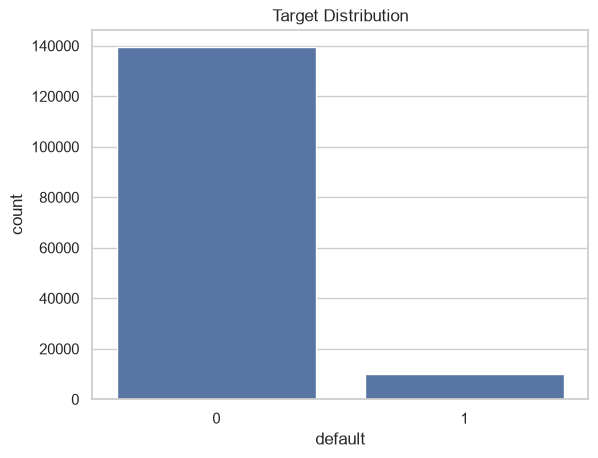

In [6]:
print(df[TARGET].value_counts())
print('\nDefault rate:', df[TARGET].mean())
sns.countplot(x=TARGET, data=df)
plt.title("Target Distribution")
plt.show()

this means we have imbalance data , so we have to choose the MLmodel which work well with the imbalance data like RandomForest 

## 4. Basic Data Quality Check


In [7]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("Duplicates:", df.duplicated().sum())

Missing values:
default                 0
util_rate               0
age                     0
late_30_59              0
debt_ratio              0
income                  0
open_loans              0
late_90_plus            0
real_estate_loans       0
late_60_89              0
dependents              0
total_late              0
has_late_payment        0
income_per_dependent    0
debt_per_loan           0
dtype: int64
Duplicates: 158


In [8]:
df = df.drop_duplicates()

## 5. Quick Statistics Overview


In [9]:
df.describe().T
print(df.skew(numeric_only=True).sort_values(ascending=False))

income                  126.824369
income_per_dependent    105.504799
debt_per_loan           102.411922
util_rate                97.381681
debt_ratio               94.933456
late_60_89               25.925295
total_late               25.851344
late_90_plus             25.589031
late_30_59               24.918361
real_estate_loans         3.485303
default                   3.462575
dependents                1.618774
has_late_payment          1.476737
open_loans                1.223361
age                       0.192670
dtype: float64


high skewness so we need to use Tree-Based Models
not sensetive to skewness



## 6. Distribution of Features


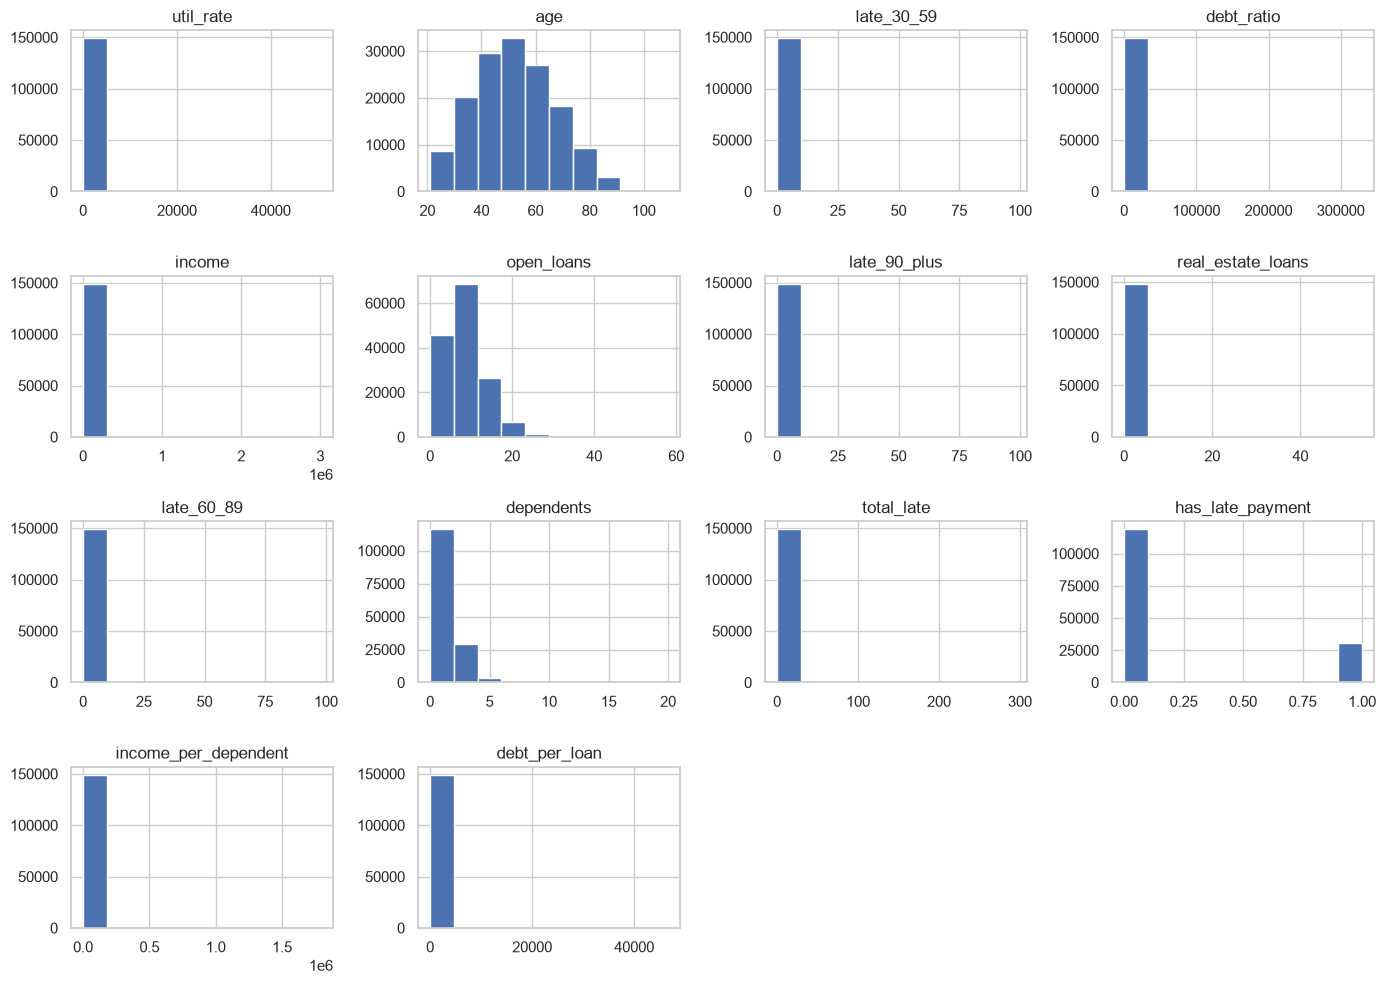

In [10]:
df[FEATURES].hist(figsize=(14,10))
plt.tight_layout()
plt.show()

## 7. Correlation Analysis


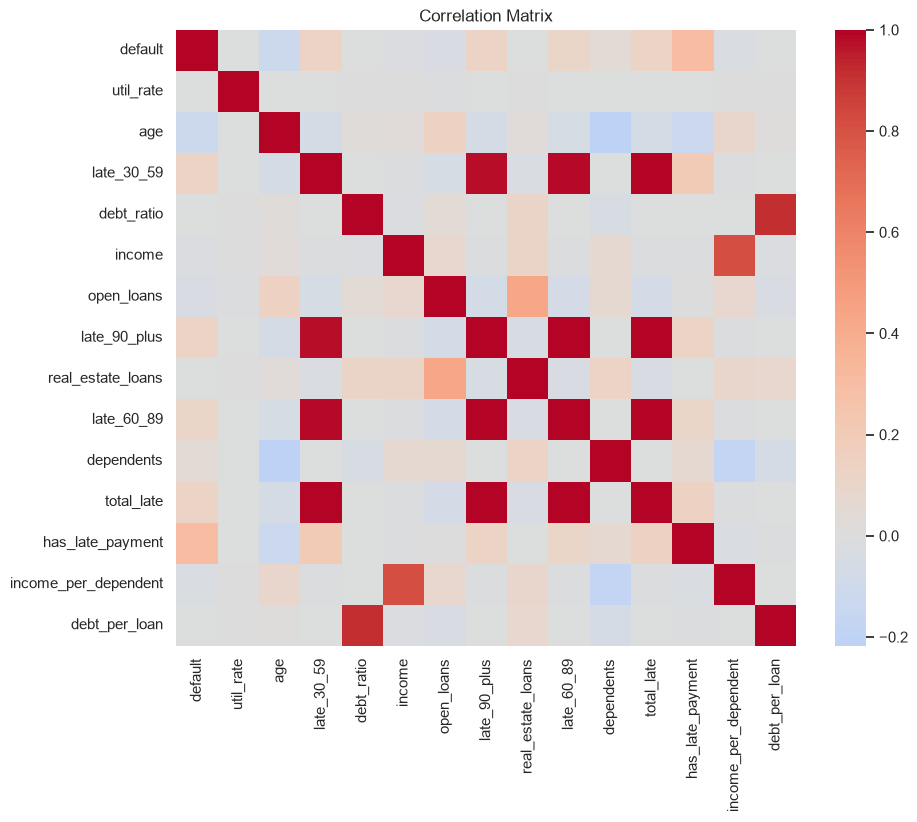

default                 1.000000
has_late_payment        0.314096
late_30_59              0.131798
late_90_plus            0.122627
total_late              0.120822
late_60_89              0.106064
dependents              0.046461
util_rate              -0.001822
debt_per_loan          -0.005964
debt_ratio             -0.007747
real_estate_loans      -0.007771
income                 -0.017279
income_per_dependent   -0.026653
open_loans             -0.030727
age                    -0.115581
Name: default, dtype: float64

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()
corr[TARGET].sort_values(ascending=False)

كل ما التأخير يزيد → probability of default يزيد

كل ما السن يزيد → default يقل


we have to make combine features between late_30_59
late_60_89
late_90_plus because they are correlated

In [12]:
df['total_late'] = df['late_30_59'] + df['late_60_89'] + df['late_90_plus']

## 8. Feature vs Target Analysis

In [13]:
for col in FEATURES:
    print("\n", col)
    print(df.groupby(TARGET)[col].mean())


 util_rate
default
0    6.199365
1    4.374687
Name: util_rate, dtype: float64

 age
default
0    52.754340
1    45.954318
Name: age, dtype: float64

 late_30_59
default
0    0.254854
1    2.246801
Name: late_30_59, dtype: float64

 debt_ratio
default
0    359.050473
1    295.767874
Name: debt_ratio, dtype: float64

 income
default
0    6486.625215
1    5593.804178
Name: income, dtype: float64

 open_loans
default
0    8.530371
1    7.899540
Name: open_loans, dtype: float64

 late_90_plus
default
0    0.109101
1    1.948920
Name: late_90_plus, dtype: float64

 real_estate_loans
default
0    1.025828
1    0.990704
Name: real_estate_loans, dtype: float64

 late_60_89
default
0    0.100590
1    1.685126
Name: late_60_89, dtype: float64

 dependents
default
0    0.727370
1    0.933327
Name: dependents, dtype: float64

 total_late
default
0    0.464544
1    5.880848
Name: total_late, dtype: float64

 has_late_payment
default
0    0.169139
1    0.674330
Name: has_late_payment, dtype: float6

## 9. Outlier Detection (IQR)

In [14]:
outlier_summary = []

for col in FEATURES:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "feature": col,
        "outliers_count": len(outliers),
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,outliers_count,lower_bound,upper_bound
0,util_rate,769,-0.758413,1.344582
1,age,44,8.000000,96.000000
2,late_30_59,23928,0.000000,0.000000
3,debt_ratio,31276,-0.870391,1.925579
4,income,9093,-1363.500000,12672.500000
5,open_loans,3980,-4.000000,20.000000
6,late_90_plus,8272,0.000000,0.000000
7,real_estate_loans,793,-3.000000,5.000000
8,late_60_89,7550,0.000000,0.000000
9,dependents,13336,-1.500000,2.500000


outliers = high risk customers 
outliers are not problem

## 10.Binning Analysis 


age_bin
(0, 30]      0.117149
(30, 45]     0.093171
(45, 60]     0.068245
(60, 100]    0.030162
Name: default, dtype: float64


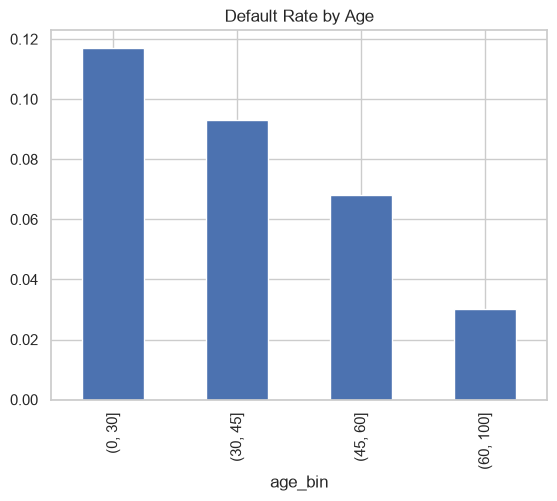

In [15]:
df['age_bin'] = pd.cut(df['age'], bins=[0,30,45,60,100])

age_default = df.groupby('age_bin')[TARGET].mean()

print(age_default)

age_default.plot(kind='bar')
plt.title("Default Rate by Age")
plt.show()

under 30 = high risk

## 11.Aggregated Features Insight

In [16]:

print(df.groupby(TARGET)['total_late'].mean())

default
0    0.464544
1    5.880848
Name: total_late, dtype: float64


## 12.Class Imbalance Confirmation

In [17]:
df[TARGET].value_counts(normalize=True)

default
0    0.932964
1    0.067036
Name: proportion, dtype: float64

In [18]:
out_path = os.path.abspath(os.path.join('..', 'data', 'readydata.csv'))
df.to_csv(out_path, index=False) 
print(f'Saved to: {out_path}')

Saved to: c:\Users\User\Downloads\Credit-risk-prediction-main\Credit-risk-prediction-main\data\readydata.csv
